In [2]:
import matplotlib.pyplot as plt
import csv
import numpy as np

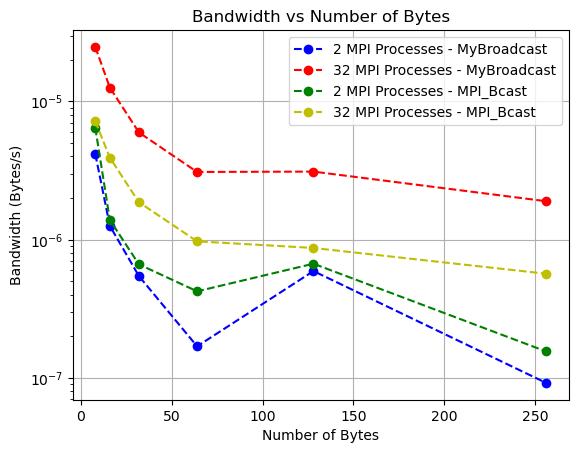

In [10]:
x = []
y_t4 = []
y_t2 = []
y_b_t4 = []
y_b_t2 = []
# bytews, process, time
# 8,4,3.338e-05
with open('./my_broadcast.csv','r') as csvfile:
    plots = csv.reader(csvfile, delimiter = ',')
    
    for row in plots:
        if int(row[1]) == 4:
            y_t4.append(float(row[2])/float(row[0]))  
        else:
            x.append(int(row[0]))
            y_t2.append(float(row[2])/float(row[0]))


plt.plot(x, y_t4, '--bo', label = "2 MPI Processes - MyBroadcast")
plt.plot(x, y_t2, '--ro', label = "32 MPI Processes - MyBroadcast")

with open('./mpi_broadcast.csv','r') as csvfile:
    plots = csv.reader(csvfile, delimiter = ',')
    
    for row in plots:
        if int(row[1]) == 4:
            y_b_t4.append(float(row[2])/float(row[0]))  
        else:
            y_b_t2.append(float(row[2])/float(row[0]))

plt.plot(x, y_b_t4, '--go', label = "2 MPI Processes - MPI_Bcast")
plt.plot(x, y_b_t2, '--yo', label = "32 MPI Processes - MPI_Bcast")

# plt.yscale('log')
plt.xlabel('Number of Bytes')
plt.ylabel('Bandwidth (Bytes/s)')
plt.title('Bandwidth vs Number of Bytes')
plt.legend(loc='upper right')
plt.yscale('log')
plt.grid()
plt.show()

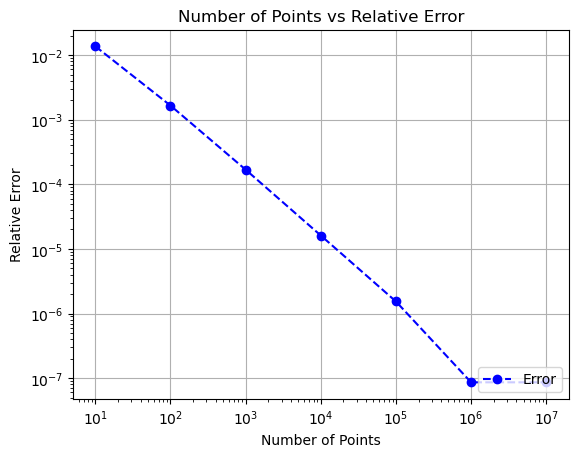

In [7]:
x = []
y = []
# par_sum, time, num_points, num_threads
# 6.16676,1.53468,100000000,1
actual_value = (35/8) + np.log(6)
with open('./numerical_error.csv','r') as csvfile:
    plots = csv.reader(csvfile, delimiter = ',')
    
    for row in plots:
        x.append(int(row[2]))
        y.append(np.abs(float(row[0]) - actual_value)/actual_value)

plt.plot(x, y, '--bo', label = "Error")

# plt.yscale('log')
plt.xlabel('Number of Points')
plt.ylabel('Relative Error')
plt.title('Number of Points vs Relative Error')
plt.legend(loc='lower right')
plt.xscale('log')
plt.yscale('log')
plt.grid()
plt.show()